# SMS Spam Detection

A cleaner, leakage-free rewrite of the original spam classification pipeline.

**Pipeline:** load & clean data → EDA → text preprocessing → train/test split → TF-IDF → baseline vs. models → evaluation (beyond accuracy) → cross-validation → save model → sanity-check on new messages.

**Key fixes vs. the original notebook:**
- TF-IDF is now fit **only on the training set** (previously fit on the full dataset before splitting — data leakage).
- Split is **stratified** so train/test preserve the ~87/13 ham/spam ratio.
- Evaluation goes beyond accuracy: precision/recall/F1 and a confusion matrix, since the classes are imbalanced.
- Adds a dummy baseline so the model's accuracy has context.
- Adds EDA (class balance, message length by class).
- Adds lemmatization, cross-validation, and model persistence.


## 1. Imports & setup

In [1]:
import re
import string
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

True

## 2. Load & clean data

In [2]:
df = pd.read_csv('encoded-spam.csv', encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
# The source CSV has stray unnamed columns from unescaped commas in a few
# messages -- they're almost entirely empty and not needed.
df = df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], errors='ignore')
df = df.rename(columns={'v1': 'is_spam', 'v2': 'message'})
df.shape

(5572, 2)

In [4]:
print('Missing values:')
print(df.isnull().sum())

print('\nDuplicate rows:', df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print('Shape after dropping duplicates:', df.shape)

Missing values:
is_spam    0
message    0
dtype: int64

Duplicate rows: 403
Shape after dropping duplicates: (5169, 2)


In [5]:
df['is_spam'] = df['is_spam'].map({'ham': 0, 'spam': 1})
df.head()

,is_spam,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


## 3. Exploratory data analysis

Before modeling: how imbalanced are the classes, and does message length carry
signal? (Spam messages tend to run longer -- this alone is a useful feature.)

is_spam
ham     4516
spam     653
Name: count, dtype: int64

Baseline: always predicting 'ham' gets 87.4% accuracy.
Keep this in mind when judging model accuracy below -- a model needs to
clear this bar by a meaningful margin, and accuracy alone won't show *how*.


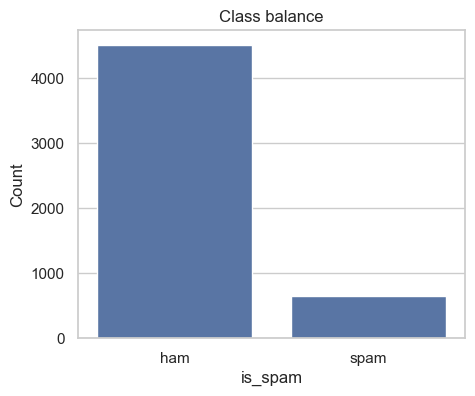

In [6]:
class_counts = df['is_spam'].value_counts().rename({0: 'ham', 1: 'spam'})
print(class_counts)
print(f"\nBaseline: always predicting 'ham' gets {class_counts['ham'] / len(df):.1%} accuracy.")
print("Keep this in mind when judging model accuracy below -- a model needs to")
print("clear this bar by a meaningful margin, and accuracy alone won't show *how*.")

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, ax=ax)
ax.set_title('Class balance')
ax.set_ylabel('Count')
plt.show()

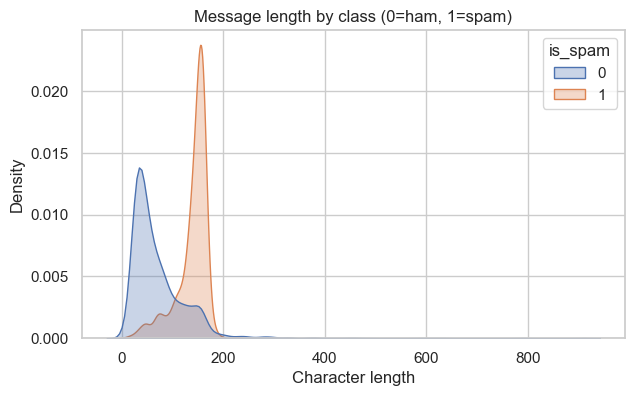

,count,mean,std,min,25%,50%,75%,max
is_spam,,,,,,,,
0,4516.0,70.590788,56.40539,2.0,34.0,52.0,90.0,910.0
1,653.0,138.742726,30.41948,13.0,132.0,149.0,158.0,226.0


In [7]:
df['msg_length'] = df['message'].str.len()

fig, ax = plt.subplots(figsize=(7, 4))
sns.kdeplot(data=df, x='msg_length', hue='is_spam', common_norm=False, ax=ax, fill=True, alpha=0.3)
ax.set_title('Message length by class (0=ham, 1=spam)')
ax.set_xlabel('Character length')
plt.show()

df.groupby('is_spam')['msg_length'].describe()

## 4. Text preprocessing

Lowercase → strip punctuation → strip digits → remove stopwords → lemmatize.
(`msg_length` was computed from the *raw* text above, before any of this.)

In [8]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(txt: str) -> str:
    txt = txt.lower()
    txt = txt.translate(str.maketrans('', '', string.punctuation))
    txt = re.sub(r'\d+', '', txt)
    words = txt.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return ' '.join(words)

df['clean_message'] = df['message'].apply(clean_text)
df[['message', 'clean_message']].head()

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think go usf life around though


## 5. Train/test split -- BEFORE vectorization

This is the important fix: the TF-IDF vectorizer must only ever see the
training text. Fitting it on the full dataset first (as in the original
notebook) leaks test-set vocabulary and document frequencies into training.

`stratify=y` also keeps the ~87/13 ham/spam ratio consistent across both splits,
which matters given how few spam examples there are.

In [9]:
X_text = df['clean_message']
y = df['is_spam']

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=20000)
X_train = vectorizer.fit_transform(X_train_text)   # fit ONLY on train
X_test = vectorizer.transform(X_test_text)          # transform only

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

Train shape: (4135, 20000)
Test shape: (1034, 20000)


## 6. Baseline

A trivial "always predict the majority class" baseline, so the models'
scores below have something meaningful to beat.

In [10]:
baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train, y_train)
y_pred_base = baseline.predict(X_test)

print(f'Baseline accuracy: {accuracy_score(y_test, y_pred_base):.4f}')
print(classification_report(y_test, y_pred_base, target_names=['ham', 'spam'], zero_division=0))

Baseline accuracy: 0.8733
              precision    recall  f1-score   support

         ham       0.87      1.00      0.93       903
        spam       0.00      0.00      0.00       131

    accuracy                           0.87      1034
   macro avg       0.44      0.50      0.47      1034
weighted avg       0.76      0.87      0.81      1034



## 7. Train models

Three models for comparison. `class_weight='balanced'` on the linear models
helps compensate for the class imbalance.

In [11]:
models = {
    'Multinomial NB': MultinomialNB(),
    'Linear SVC': LinearSVC(class_weight='balanced', random_state=42),
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
}

results = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[name] = y_pred
    results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'f1_spam': f1_score(y_test, y_pred, pos_label=1),
    }

results_df = pd.DataFrame(results).T.sort_values('f1_spam', ascending=False)
results_df

,accuracy,f1_spam
Linear SVC,0.983559,0.933852
Logistic Regression,0.970986,0.888060
Multinomial NB,0.952611,0.769953


## 8. Evaluation beyond accuracy

For spam detection, **recall on spam** (how much spam slips through) and
**precision on spam** (how many real messages get wrongly flagged) matter more
than overall accuracy. Full report + confusion matrix for each model:

--- Multinomial NB ---
              precision    recall  f1-score   support

         ham       0.95      1.00      0.97       903
        spam       1.00      0.63      0.77       131

    accuracy                           0.95      1034
   macro avg       0.97      0.81      0.87      1034
weighted avg       0.96      0.95      0.95      1034

--- Linear SVC ---
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       903
        spam       0.95      0.92      0.93       131

    accuracy                           0.98      1034
   macro avg       0.97      0.95      0.96      1034
weighted avg       0.98      0.98      0.98      1034

--- Logistic Regression ---
              precision    recall  f1-score   support

         ham       0.99      0.98      0.98       903
        spam       0.87      0.91      0.89       131

    accuracy                           0.97      1034
   macro avg       0.93      0.94      0.94      1034
weig

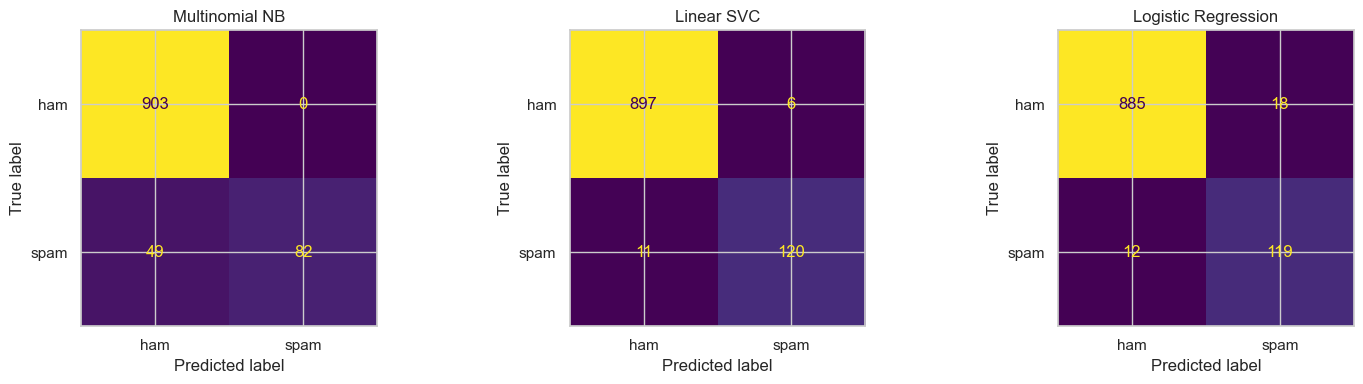

In [12]:
fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 4))
if len(models) == 1:
    axes = [axes]

for ax, (name, y_pred) in zip(axes, predictions.items()):
    print(f'--- {name} ---')
    print(classification_report(y_test, y_pred, target_names=['ham', 'spam']))
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['ham', 'spam']).plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

## 9. Cross-validation

A single 80/20 split on ~5,000 rows (and only ~130 spam examples in the test
set) gives a noisy accuracy estimate. 5-fold stratified cross-validation on
the best model gives a more reliable picture. Note this refits the vectorizer
inside each fold via a pipeline, so there's no leakage here either.

In [17]:
best_model_name = results_df.index[0]

from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), max_features=20000)),
    ('clf', models[best_model_name]),
])

cv_scores = cross_val_score(pipeline, X_text, y, cv=5, scoring='f1')
print(f'F1 (spam) per fold: {cv_scores.round(3)}')
print(f'Mean F1: {cv_scores.mean():.3f}')

F1 (spam) per fold: [0.89  0.909 0.916 0.898 0.895]
Mean F1: 0.902


## 10. Save the trained model

Persist the fitted vectorizer and best model so they can be reused without
retraining.

In [18]:
import joblib

best_model = models[best_model_name]
joblib.dump(vectorizer, 'tfidf_vectorizer.joblib')
joblib.dump(best_model, 'spam_classifier.joblib')
print(f'Saved vectorizer and {best_model_name} model to disk.')

Saved vectorizer and Linear SVC model to disk.


## 11. Sanity check on new messages

A quick end-to-end check that the saved pipeline behaves sensibly on
messages it has never seen.

In [19]:
def predict_message(text):
    text = clean_text(text)
    vec = vectorizer.transform([text])
    pred = best_model.predict(vec)[0]

    if pred == 1:
        return "spam"
    return "ham"


sample_messages = [
    "Hey, are we still on for lunch tomorrow?",
    "WINNER!! You have been selected to receive a FREE cash prize of $1000. Call now to claim!",
    "Can you send me the report before end of day?",
    "URGENT: your account has been suspended, click here to verify your details immediately"
]

for msg in sample_messages:
    print(predict_message(msg), ":", msg)

ham : Hey, are we still on for lunch tomorrow?
spam : WINNER!! You have been selected to receive a FREE cash prize of $1000. Call now to claim!
ham : Can you send me the report before end of day?
spam : URGENT: your account has been suspended, click here to verify your details immediately
